# TP1 — Regresión e Introducción a la evaluación de modelos
**72.75 Aprendizaje Automático — 2026 Q2**

Dataset elegido: **Insurance Charges** (predecir `charges`, el costo médico anual).

Integrantes: _completar_ · Fecha de defensa: 26/08/2026

---
## Introducción teórica — Separación train / validación / test

- **Train**: los datos con los que el modelo ajusta sus parámetros (los pesos $w$).
- **Validación (dev)**: datos que el modelo *no* vio al entrenar, usados para **elegir**
  hiperparámetros (grado del polinomio, $\lambda$, qué features usar). Como los elegimos
  mirando este conjunto, el error de validación queda **sesgado hacia abajo**: es optimista.
- **Test**: se toca **una sola vez**, al final, con el modelo ya elegido. Es la única
  estimación honesta del error de generalización $E_{out}$.

**Por qué es necesario:** el error de train no mide capacidad de generalizar — un modelo con
suficiente complejidad puede memorizar el train y tener error casi nulo (overfitting) mientras
falla en datos nuevos. Necesitamos datos que el modelo nunca vio para estimar cómo va a
funcionar en producción. Y necesitamos *dos* conjuntos separados porque cada vez que usamos
un conjunto para **decidir** algo, lo contaminamos.

**Cross-validation (k-fold):** en lugar de partir el train en un único train/dev (y perder datos
+ depender de la suerte de esa partición), lo partimos en $k$ folds y rotamos: entrenamos con
$k-1$ y validamos con el restante, $k$ veces. El error de validación es el promedio de los $k$.
Ventaja: usamos todos los datos para validar, y la **dispersión entre folds** nos dice cuán
confiable es la estimación.

## 0. Setup y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42          # semilla fija -> resultados reproducibles
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

df = pd.read_csv("insurance.csv")
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


---
# 1. Limpieza de datos

## 1.1 Variables categóricas

El dataset tiene 3 variables categóricas: `sex`, `smoker` y `region`. Un modelo de regresión
lineal sólo opera sobre números, así que hay que codificarlas.

**Decisión: one-hot encoding con `drop='first'`.**

*Justificación:*
- **Por qué one-hot y no label encoding (0,1,2,3):** un label encoding le impondría un
  **orden y una distancia artificial** a las categorías. Decir `northeast=0, northwest=1,
  southeast=2, southwest=3` haría que el modelo asuma que southwest está "3 veces más lejos"
  de northeast que northwest — algo que no significa nada. `region` es **nominal**, no ordinal.
- **Por qué `drop='first'`:** con las $k$ columnas completas, la suma de las dummies da siempre 1,
  que es exactamente la columna de bias → **colinealidad perfecta** (*dummy variable trap*), la
  matriz $X^TX$ queda singular. Dropeando una categoría, ésta pasa a ser la **referencia** y los
  coeficientes de las demás se leen como "diferencia respecto de la referencia".
- `sex` y `smoker` son binarias: quedan en una sola columna 0/1.

`children` es numérica discreta (0–5) y la dejamos como numérica: acá el orden **sí** significa
algo (3 hijos es más que 1) y la relación con el costo es aproximadamente monótona.

In [3]:
cat_cols = ['sex', 'smoker', 'region']
num_cols = ['age', 'bmi', 'children']

for c in cat_cols:
    print(c, '->', dict(df[c].value_counts()))

# Vista previa de cómo queda la codificación (el encoding real va dentro del Pipeline)
pd.get_dummies(df[cat_cols], drop_first=True).head()

sex -> {'male': np.int64(676), 'female': np.int64(662)}
smoker -> {'no': np.int64(1064), 'yes': np.int64(274)}
region -> {'southeast': np.int64(364), 'southwest': np.int64(325), 'northwest': np.int64(325), 'northeast': np.int64(324)}


,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,False,True,False,False,True
1,True,False,False,True,False
2,True,False,False,True,False
3,True,False,True,False,False
4,True,False,True,False,False


## 1.2 Valores faltantes

**Resultado: no hay valores faltantes.** Ninguna columna tiene NaN, así que no hace falta
aplicar ninguna estrategia de imputación.

Sí encontramos **1 fila exactamente duplicada**. La eliminamos: una fila repetida le da doble
peso a esa observación y, peor, si cae en folds distintos del cross-validation genera una fuga
de información (el modelo valida sobre un registro idéntico a uno que entrenó).

In [4]:
print("Nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())
display(df[df.duplicated(keep=False)])

df = df.drop_duplicates().reset_index(drop=True)
print("\nShape final:", df.shape)

Nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Filas duplicadas: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631



Shape final: (1337, 7)


## 1.3 Outliers

**Criterio de detección: regla del rango intercuartílico (IQR).** Se marca como atípico todo
valor fuera de $[Q_1 - 1.5\cdot IQR,\; Q_3 + 1.5\cdot IQR]$. Elegimos IQR sobre el z-score
porque `charges` está fuertemente sesgada a derecha (skew ≈ 1.5) y el z-score asume normalidad:
con una cola larga, la media y el desvío ya están contaminados por los propios outliers.

**Decisión: NO eliminamos ningún outlier.** Justificación por variable:

| Variable | Atípicos (IQR) | Decisión | Por qué |
|---|---|---|---|
| `charges` | ~139 | **Mantener** | No son errores: son casi todos **fumadores**. La media de un fumador es ~32.050 vs ~8.434 de un no fumador. Esos valores altos son la *señal* que el modelo tiene que aprender, no ruido. Borrarlos sería enseñarle al modelo un mundo que no existe. |
| `bmi` | ~9 | **Mantener** | Valores hasta 53.13 son fisiológicamente posibles (obesidad severa) y son justo la población de mayor riesgo. |
| `age`, `children` | 0 | — | Rangos válidos (18–64 y 0–5). |

**Regla general:** un outlier se elimina cuando es un **error de medición o de carga**; se
conserva cuando es un caso real y raro. Acá son todos casos reales.

In [5]:
def outliers_iqr(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lo) | (s > hi))

for c in num_cols + ['charges']:
    m = outliers_iqr(df[c])
    print(f"{c:9s} outliers IQR: {m.sum():4d}  ({m.mean()*100:.1f}%)")

# ¿Quiénes son los outliers de charges?
m = outliers_iqr(df['charges'])
print("\nOutliers de charges por condición de fumador:")
print(df.loc[m, 'smoker'].value_counts())
print("\nMedia de charges por grupo:")
print(df.groupby('smoker')['charges'].agg(['mean', 'median', 'count']).round(1))

age       outliers IQR:    0  (0.0%)
bmi       outliers IQR:    9  (0.7%)
children  outliers IQR:    0  (0.0%)
charges   outliers IQR:  139  (10.4%)

Outliers de charges por condición de fumador:
smoker
yes    136
no       3
Name: count, dtype: int64

Media de charges por grupo:
           mean   median  count
smoker                         
no       8440.7   7345.7   1063
yes     32050.2  34456.3    274


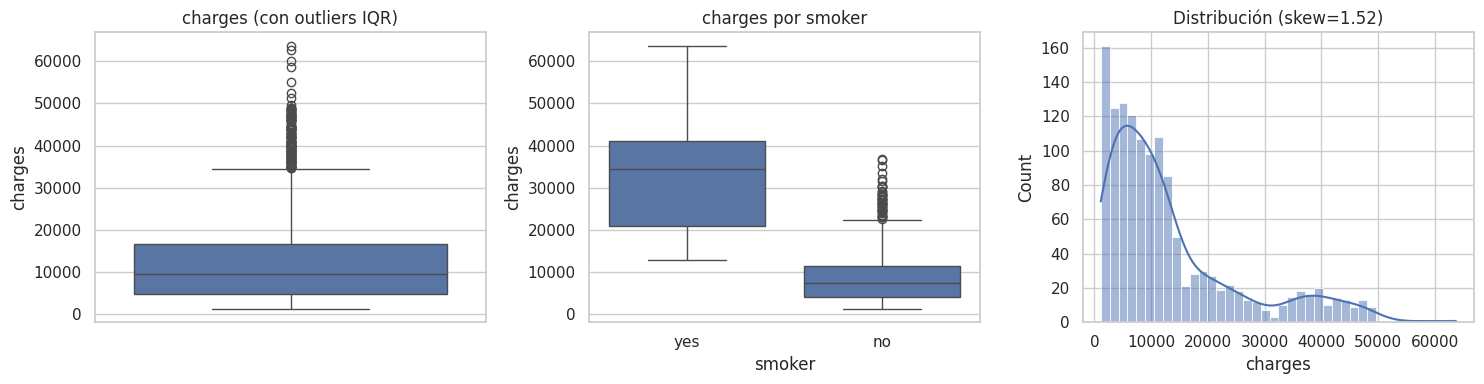

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['charges'], ax=ax[0]); ax[0].set_title('charges (con outliers IQR)')
sns.boxplot(data=df, x='smoker', y='charges', ax=ax[1]); ax[1].set_title('charges por smoker')
sns.histplot(df['charges'], bins=40, kde=True, ax=ax[2]); ax[2].set_title(f'Distribución (skew={df.charges.skew():.2f})')
plt.tight_layout(); plt.show()

## 1.4 Características y escalado

**Qué features incluimos: todas (age, bmi, children, sex, smoker, region).**

*Justificación:* son sólo 6 variables — no hay problema de dimensionalidad y ninguna es
redundante. El EDA de abajo muestra que `smoker` es con diferencia la más predictiva
(la separación entre grupos es enorme), `age` y `bmi` tienen correlación moderada positiva
con el target, y `sex`/`region` aportan poco pero tampoco molestan. Además, la regularización
L1 (punto 3.3) se encarga de podar automáticamente lo que no sirva, así que dejamos que el
modelo lo decida en vez de descartar a mano.

**Escalado: sí, `StandardScaler` (z-score), aplicado *dentro* del pipeline.**

*Justificación:*
- Para OLS puro el escalado **no cambia el RMSE** (la solución es equivalente), pero
- es **imprescindible para Lasso/Ridge**: la penalización $\lambda\sum|w_j|$ castiga a todos los
  coeficientes por igual, y sin escalar, una variable con unidades grandes tiene coeficiente chico
  y se penaliza menos → la regularización dependería de las unidades, no de la relevancia.
- también mejora el **condicionamiento numérico** de las features polinómicas (con grado 3,
  $age^3 \approx 260.000$ convive con dummies de 0/1).

> **Punto clave — data leakage:** el scaler se ajusta (`.fit`) **sólo con el train de cada fold**,
> nunca con el dataset completo. Si calculáramos media y desvío sobre todo el dataset, información
> del conjunto de validación se filtraría al entrenamiento. Por eso todo va dentro de un
> `Pipeline` de sklearn: al llamar `.fit()` sobre el fold de entrenamiento, cada transformación
> aprende sus parámetros sólo con esos datos.

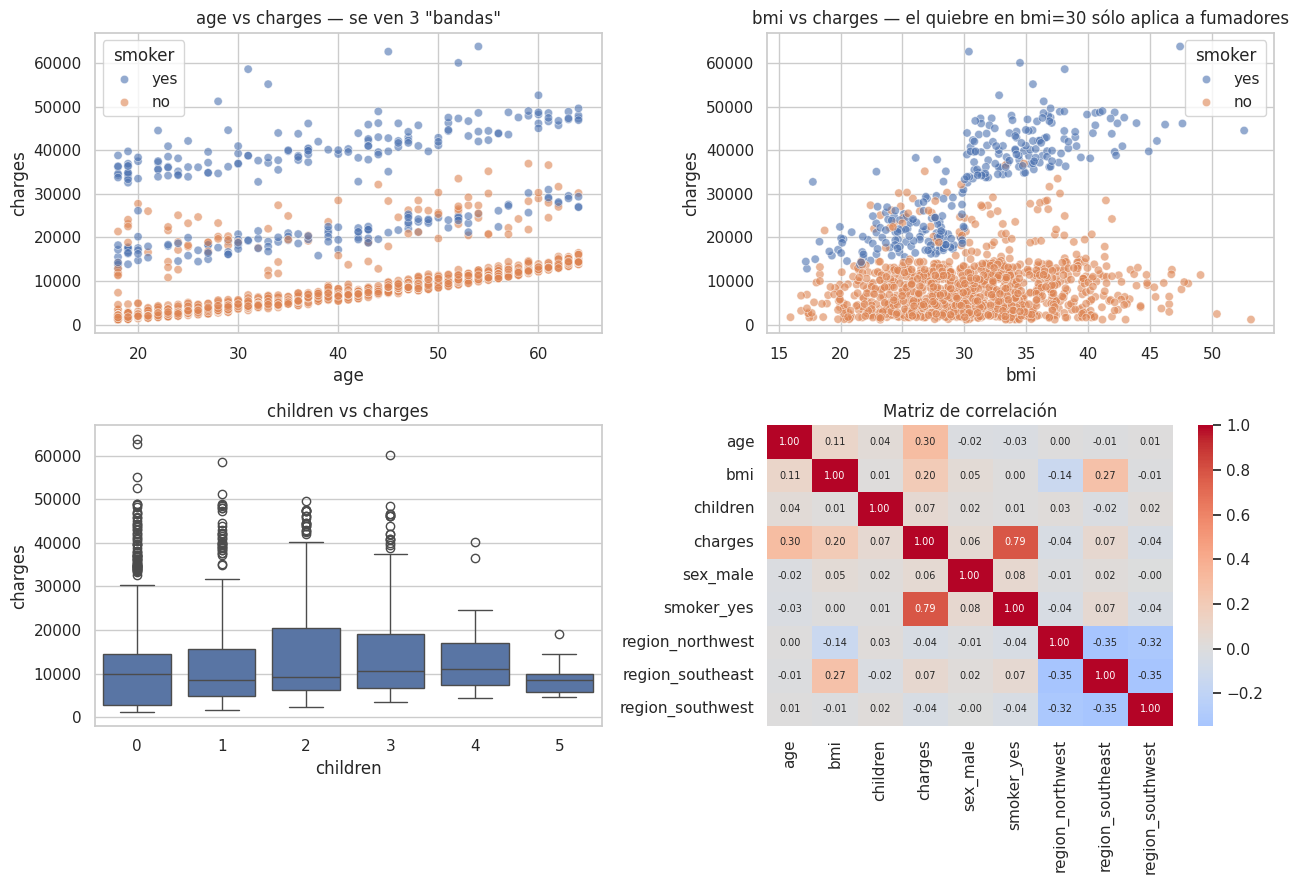

charges             1.000
smoker_yes          0.787
age                 0.298
bmi                 0.198
region_southeast    0.074
children            0.067
sex_male            0.058
region_northwest   -0.039
region_southwest   -0.044
Name: charges, dtype: float64


In [7]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=.6, ax=ax[0,0])
ax[0,0].set_title('age vs charges — se ven 3 "bandas"')
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=.6, ax=ax[0,1])
ax[0,1].set_title('bmi vs charges — el quiebre en bmi=30 sólo aplica a fumadores')
sns.boxplot(data=df, x='children', y='charges', ax=ax[1,0]); ax[1,0].set_title('children vs charges')
d = pd.get_dummies(df, drop_first=True).astype(float)
sns.heatmap(d.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[1,1], annot_kws={'size':7})
ax[1,1].set_title('Matriz de correlación')
plt.tight_layout(); plt.show()

print(d.corr()['charges'].sort_values(ascending=False).round(3))

**Lectura del EDA (para la presentación):**

- `smoker` es la variable dominante: correlación 0.79 con `charges`.
- En `age vs charges` se ven **tres bandas** paralelas → hay estructura que un modelo lineal
  simple no captura del todo.
- En `bmi vs charges`, el efecto del BMI se dispara **sólo en fumadores** y a partir de BMI≈30.
  Eso es una **interacción** `bmi × smoker`: justamente el tipo de término que la
  transformación polinómica del punto 3 va a poder representar y el modelo lineal plano no.

---
# 2. Regresión lineal

## 2.1 Separación de datos

**Decisión: 80% train / 20% test, con `shuffle` y estratificando por `smoker`, semilla fija.**

*Justificación:*
- **80/20**: con ~1.337 filas, el 20% son ~268 muestras de test — suficiente para estimar el
  error sin sacarle demasiados datos al entrenamiento. Con datasets chicos no conviene reservar
  más; con millones de filas se usarían proporciones tipo 98/1/1.
- **Shuffle**: el CSV podría venir ordenado por alguna variable; mezclar evita que train y test
  representen poblaciones distintas.
- **Estratificar por `smoker`**: es la variable más predictiva y está desbalanceada (~20% fumadores).
  Sin estratificar, el azar puede dejar proporciones distintas en train y test y el RMSE de test
  se vuelve mucho más ruidoso.
- **`random_state` fijo**: reproducibilidad — cualquiera que corra el notebook obtiene lo mismo.

> **Regla del test set:** a partir de acá, `X_test` **no se toca** hasta el punto 5. Todas las
> decisiones (grado, $\lambda$) se toman con cross-validation sobre el train.

In [8]:
X = df[num_cols + cat_cols]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=df['smoker'])

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"% fumadores  ->  train: {(X_train.smoker=='yes').mean():.3f} | test: {(X_test.smoker=='yes').mean():.3f}")

Train: 1069 filas | Test: 268 filas
% fumadores  ->  train: 0.205 | test: 0.205


## 2.2 Validación cruzada (k-fold)

**Decisión: k = 5, con shuffle y semilla fija, aplicado únicamente sobre el conjunto de train.**

*Justificación de k=5:* es el compromiso estándar. Con k chico (2–3) cada modelo entrena con
pocos datos y el error queda pesimista; con k muy grande (LOO) el costo computacional se dispara
y la estimación tiene más varianza. Con k=5 cada fold valida sobre ~214 muestras y entrenamos
sobre ~855.

La función de abajo arma el **pipeline** (encoding → polinomio → escalado → modelo) y lo
re-entrena desde cero en cada fold. Reportamos RMSE de train y de validación promediados sobre
los 5 folds, más el desvío entre folds.

In [9]:
def build_pipeline(degree=1, alpha=None):
    """encoding -> (polinomio) -> escalado -> modelo. Todo dentro del Pipeline: sin data leakage."""
    pre = ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)])
    steps = [('pre', pre)]
    if degree > 1:
        steps.append(('poly', PolynomialFeatures(degree=degree, include_bias=False)))
    steps.append(('scaler', StandardScaler()))
    steps.append(('model', LinearRegression() if alpha is None
                           else Lasso(alpha=alpha, max_iter=100_000)))
    return Pipeline(steps)


def cross_validate_rmse(degree=1, alpha=None, k=5, verbose=False):
    """k-fold CV sobre el TRAIN. Devuelve RMSE medio de train, de validación y su desvío."""
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    rmse_tr, rmse_va = [], []
    for i, (idx_tr, idx_va) in enumerate(kf.split(X_train), 1):
        Xa, Xb = X_train.iloc[idx_tr], X_train.iloc[idx_va]
        ya, yb = y_train.iloc[idx_tr], y_train.iloc[idx_va]
        pipe = build_pipeline(degree, alpha).fit(Xa, ya)      # fit SOLO con el fold de train
        rtr = mean_squared_error(ya, pipe.predict(Xa)) ** 0.5
        rva = mean_squared_error(yb, pipe.predict(Xb)) ** 0.5
        rmse_tr.append(rtr); rmse_va.append(rva)
        if verbose:
            print(f"  fold {i}: RMSE train = {rtr:8.1f} | RMSE val = {rva:8.1f}")
    return np.mean(rmse_tr), np.mean(rmse_va), np.std(rmse_va)

## 2.3 Entrenamiento del modelo lineal

Entrenamos la regresión lineal dentro del cross-validation y reportamos el RMSE
(*root mean squared error*):

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Usamos RMSE y no MSE porque queda en las **mismas unidades que el target** (dólares), así que
es interpretable directamente: "el modelo se equivoca en promedio X dólares".

In [10]:
print("Regresión lineal (grado 1) — 5-fold CV\n")
tr1, va1, sd1 = cross_validate_rmse(degree=1, verbose=True)
print(f"\n  RMSE train medio     : {tr1:8.1f}")
print(f"  RMSE validación medio: {va1:8.1f}  (± {sd1:.1f} entre folds)")
print(f"  Gap (val - train)    : {va1-tr1:8.1f}  -> gap chico: el modelo NO overfittea, underfittea")

Regresión lineal (grado 1) — 5-fold CV

  fold 1: RMSE train =   6423.4 | RMSE val =   5629.7
  fold 2: RMSE train =   6214.1 | RMSE val =   6508.8
  fold 3: RMSE train =   6444.5 | RMSE val =   5525.8
  fold 4: RMSE train =   6023.5 | RMSE val =   7174.2
  fold 5: RMSE train =   6181.0 | RMSE val =   6647.0

  RMSE train medio     :   6257.3
  RMSE validación medio:   6297.1  (± 628.8 entre folds)
  Gap (val - train)    :     39.8  -> gap chico: el modelo NO overfittea, underfittea


In [11]:
# Coeficientes del modelo lineal entrenado sobre todo el train (para interpretar)
pipe_lin = build_pipeline(degree=1).fit(X_train, y_train)
feat_names = pipe_lin[:-1].get_feature_names_out()
coefs = pd.Series(pipe_lin[-1].coef_, index=feat_names).sort_values(key=abs, ascending=False)
print("Coeficientes (sobre variables estandarizadas -> comparables entre sí):")
print(coefs.round(1))
print(f"\nIntercept: {pipe_lin[-1].intercept_:.1f}")

Coeficientes (sobre variables estandarizadas -> comparables entre sí):
cat__smoker_yes          9585.6
num__age                 3594.1
num__bmi                 2012.6
num__children             739.8
cat__region_southeast    -532.5
cat__region_southwest    -440.3
cat__region_northwest    -154.6
cat__sex_male            -128.9
dtype: float64

Intercept: 13355.9


---
# 3. Regresión polinómica

## 3.1 Transformación polinómica

**Decisión: evaluamos grados 2 y 3** (además del grado 1 como baseline).

*Justificación:* el EDA mostró que el efecto del BMI aparece **sólo en fumadores** — una
interacción. `PolynomialFeatures` genera potencias **y productos cruzados**, así que el grado 2
crea explícitamente el término `bmi × smoker` que el modelo lineal no podía representar.
No vamos más allá de grado 3 porque la cantidad de features explota (8 → 44 → 164) y con
~1.070 filas de train el overfitting se vuelve inevitable.

> Ojo: la transformación se aplica **después** del one-hot y **dentro** del pipeline, para que
> las interacciones incluyan también a las dummies.

In [12]:
for d in [1, 2, 3]:
    n = build_pipeline(degree=d).fit(X_train, y_train)[:-1].transform(X_train).shape[1]
    print(f"grado {d}: {n:4d} features")

grado 1:    8 features
grado 2:   44 features
grado 3:  164 features


## 3.2 Entrenamiento del modelo polinómico

Mismo esquema de cross-validation, cambiando sólo el grado.

In [13]:
for d in [2, 3]:
    tr, va, sd = cross_validate_rmse(degree=d)
    print(f"Grado {d}: RMSE train = {tr:8.1f} | RMSE val = {va:8.1f} (± {sd:.1f}) | gap = {va-tr:7.1f}")

Grado 2: RMSE train =   4903.1 | RMSE val =   5036.1 (± 643.5) | gap =   133.0


Grado 3: RMSE train =   4664.0 | RMSE val =   5226.1 (± 679.8) | gap =   562.1


**Observación:** al pasar de grado 2 a grado 3 el error de **train baja** pero el de
**validación sube**, y el gap se dispara (~133 → ~562). Ése es el retrato de libro del
**overfitting**: el modelo empieza a memorizar ruido del training set.

## 3.3 Regularización L1 (Lasso)

La regularización agrega una penalización al costo para frenar la complejidad del modelo:

$$J(w) = \underbrace{\frac{1}{2n}\sum(y_i-\hat{y}_i)^2}_{\text{error}} + \underbrace{\lambda\sum_j |w_j|}_{\text{penalización L1}}$$

Con L1 (Lasso) la penalización es sobre el **valor absoluto** de los pesos, lo que empuja a
varios coeficientes exactamente a **cero** → hace *feature selection* automática. Es
especialmente útil acá, donde el grado 3 genera 164 features de las que muchas son ruido.

Probamos $\lambda \in \{1, 10, 100, 500\}$ para cada grado.

In [14]:
filas = []
for d in [1, 2, 3]:
    for a in [None, 1, 10, 100, 500]:
        tr, va, sd = cross_validate_rmse(degree=d, alpha=a)
        filas.append({'grado': d, 'lambda': 'sin reg.' if a is None else a,
                      'RMSE_train': round(tr, 1), 'RMSE_val': round(va, 1),
                      'std_val': round(sd, 1), 'gap': round(va - tr, 1)})

resultados = pd.DataFrame(filas)
resultados

,grado,lambda,RMSE_train,RMSE_val,std_val,gap
0,1,sin reg.,6257.3,6297.1,628.8,39.8
1,1,1,6257.3,6297.1,628.9,39.8
2,1,10,6257.4,6297.2,629.7,39.8
3,1,100,6265.9,6300.8,637.4,34.9
4,1,500,6353.7,6375.8,677.5,22.1
5,2,sin reg.,4903.1,5036.1,643.5,133.0
6,2,1,4903.2,5033.8,643.3,130.5
7,2,10,4914.2,5021.0,646.5,106.8
8,2,100,5083.3,5127.6,638.5,44.3
9,2,500,5412.0,5413.1,620.6,1.1


---
# 4. Evaluación

Tabla de errores de **validación** (5-fold CV sobre el train), indicando explícitamente grado y $\lambda$.

In [15]:
piv = resultados.pivot(index='lambda', columns='grado', values='RMSE_val')
display(piv.style.background_gradient(cmap='RdYlGn_r', axis=None).format('{:.1f}'))

mejor = resultados.sort_values('RMSE_val').iloc[0]
print(f"\nMEJOR CONFIGURACIÓN -> grado {mejor.grado}, lambda = {mejor['lambda']}")
print(f"  RMSE validación: {mejor.RMSE_val:.1f} (± {mejor.std_val:.1f})")
print(f"  RMSE train     : {mejor.RMSE_train:.1f}   | gap: {mejor.gap:.1f}")

grado,1,2,3
lambda,,,
1,6297.1,5033.8,5168.9
10,6297.2,5021.0,5104.7
100,6300.8,5127.6,5080.8
500,6375.8,5413.1,5181.8
sin reg.,6297.1,5036.1,5226.1



MEJOR CONFIGURACIÓN -> grado 2, lambda = 10
  RMSE validación: 5021.0 (± 646.5)
  RMSE train     : 4914.2   | gap: 106.8


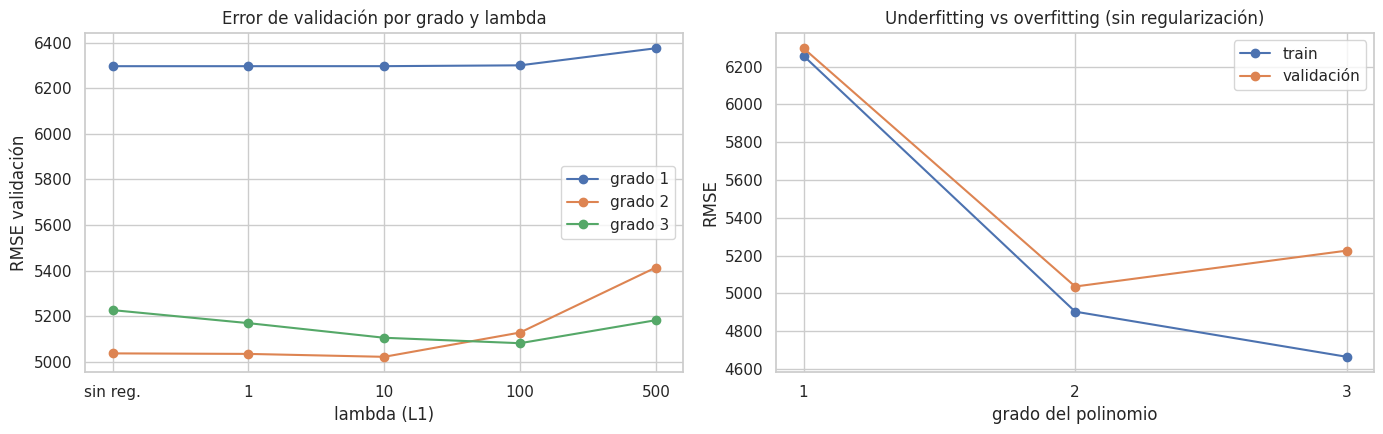

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for d in [1, 2, 3]:
    s = resultados[resultados.grado == d]
    ax[0].plot(range(len(s)), s.RMSE_val, 'o-', label=f'grado {d}')
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(['sin reg.', '1', '10', '100', '500'])
ax[0].set_xlabel('lambda (L1)'); ax[0].set_ylabel('RMSE validación'); ax[0].legend()
ax[0].set_title('Error de validación por grado y lambda')

sinreg = resultados[resultados['lambda'] == 'sin reg.']
ax[1].plot(sinreg.grado, sinreg.RMSE_train, 'o-', label='train')
ax[1].plot(sinreg.grado, sinreg.RMSE_val, 'o-', label='validación')
ax[1].set_xticks([1, 2, 3]); ax[1].set_xlabel('grado del polinomio'); ax[1].set_ylabel('RMSE')
ax[1].legend(); ax[1].set_title('Underfitting vs overfitting (sin regularización)')
plt.tight_layout(); plt.show()

**Lectura de los gráficos:**

- **Grado 1 (izq., línea azul):** el error de validación es alto y plano — la regularización no
  ayuda porque el modelo no está overfitteando, está **underfitteando** (bias alto).
- **Grado 2:** el mejor. Una $\lambda$ chica-moderada (10) mejora un poco.
- **Grado 3:** empeora sin regularización, pero **la regularización lo rescata**: de 5226 baja a
  5081 con $\lambda=100$. Aun así no llega al grado 2.
- **Derecha:** la curva clásica de bias-variance. De grado 1 a 2 bajan ambos errores (sale del
  underfitting); de 2 a 3 el train sigue bajando pero la validación sube (entra en overfitting).

---
# 5. Comparación de modelos y evaluación final en test

Recién ahora, con el modelo **ya elegido** por cross-validation, tocamos el test set — una sola vez.

In [17]:
grado_final = int(mejor.grado)
lambda_final = None if mejor['lambda'] == 'sin reg.' else float(mejor['lambda'])

modelo_final = build_pipeline(grado_final, lambda_final).fit(X_train, y_train)
pred_test = modelo_final.predict(X_test)

rmse_test = mean_squared_error(y_test, pred_test) ** 0.5
r2_test = r2_score(y_test, pred_test)
baseline = mean_squared_error(y_test, np.full(len(y_test), y_train.mean())) ** 0.5

print(f"MODELO FINAL: polinomio grado {grado_final}, Lasso lambda={lambda_final}")
print(f"  RMSE test           : {rmse_test:8.1f}")
print(f"  R² test             : {r2_test:8.3f}")
print(f"  RMSE validación (CV): {mejor.RMSE_val:8.1f}")
print(f"  Baseline (media)    : {baseline:8.1f}  -> el modelo reduce el error un {(1-rmse_test/baseline)*100:.0f}%")

MODELO FINAL: polinomio grado 2, Lasso lambda=10.0
  RMSE test           :   3890.4
  R² test             :    0.895
  RMSE validación (CV):   5021.0
  Baseline (media)    :  12012.6  -> el modelo reduce el error un 68%


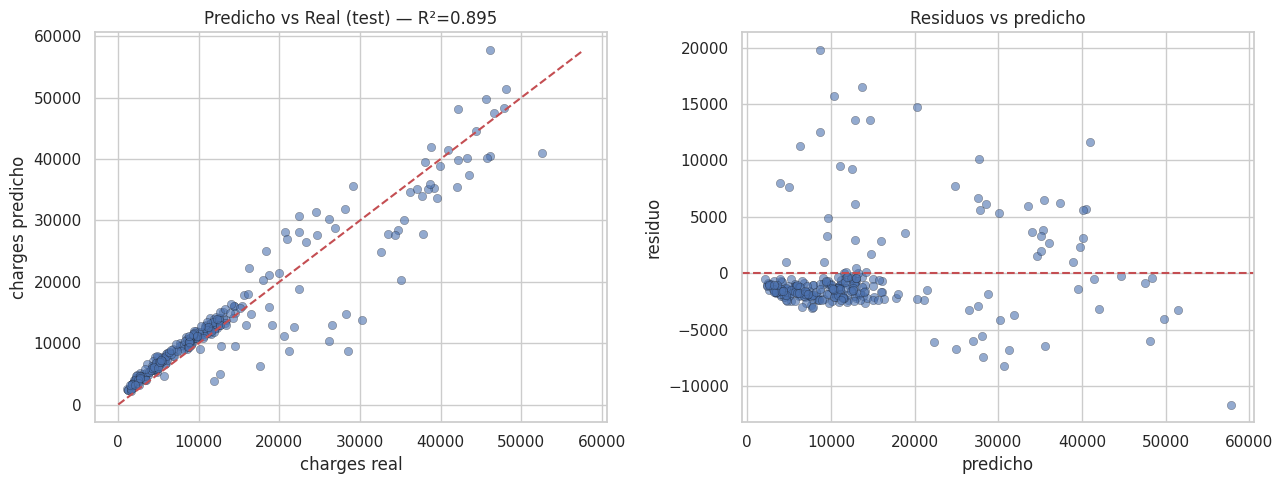

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, pred_test, alpha=.6, edgecolor='k', linewidth=.3)
lims = [0, max(y_test.max(), pred_test.max())]
ax[0].plot(lims, lims, 'r--'); ax[0].set_xlabel('charges real'); ax[0].set_ylabel('charges predicho')
ax[0].set_title(f'Predicho vs Real (test) — R²={r2_test:.3f}')

resid = y_test - pred_test
ax[1].scatter(pred_test, resid, alpha=.6, edgecolor='k', linewidth=.3)
ax[1].axhline(0, color='r', ls='--'); ax[1].set_xlabel('predicho'); ax[1].set_ylabel('residuo')
ax[1].set_title('Residuos vs predicho')
plt.tight_layout(); plt.show()

## ¿Cuán estable es esta estimación?

El RMSE de test depende de **qué 268 filas** cayeron en el test. Repetimos todo el
procedimiento con 10 particiones distintas para medir esa variabilidad — este es el análisis
que justifica la respuesta a la pregunta 3.

In [19]:
val_scores, test_scores = [], []
X_train_bak, y_train_bak = X_train, y_train

for rs in range(10):
    X_train, X_te2, y_train, y_te2 = train_test_split(
        X, y, test_size=0.2, random_state=rs, stratify=df['smoker'])
    _, va, _ = cross_validate_rmse(grado_final, lambda_final)
    p = build_pipeline(grado_final, lambda_final).fit(X_train, y_train)
    val_scores.append(va)
    test_scores.append(mean_squared_error(y_te2, p.predict(X_te2)) ** 0.5)

X_train, y_train = X_train_bak, y_train_bak   # restaurar

print(f"RMSE validación (CV): media {np.mean(val_scores):.0f}  rango [{min(val_scores):.0f}, {max(val_scores):.0f}]")
print(f"RMSE test           : media {np.mean(test_scores):.0f}  rango [{min(test_scores):.0f}, {max(test_scores):.0f}]")

RMSE validación (CV): media 4845  rango [4649, 5142]
RMSE test           : media 4953  rango [3627, 5576]


## Respuestas

### 1. ¿Qué modelo obtuvo menor error?

La **regresión polinómica de grado 2 con Lasso ($\lambda = 10$)**, con RMSE de validación
≈ **5.021** dólares, frente a ≈ **6.297** del modelo lineal simple: una **mejora del ~20%**.

El grado 3 (RMSE val ≈ 5.226 sin regularizar) es peor que el grado 2 pese a tener más
capacidad — su RMSE de *train* es el más bajo de todos (4.664), lo que confirma que la mejora
es memorización, no aprendizaje.

**Por qué el grado 2 gana:** captura la interacción `bmi × smoker` que vimos en el EDA — el
BMI encarece la póliza sólo si la persona fuma. Es un efecto real del dominio que un modelo
aditivo lineal no puede representar.

### 2. Si tuvieran que implementar uno en una aplicación real, ¿cuál elegirían?

**El polinómico de grado 2 con Lasso ($\lambda=10$)**, por:

- **Menor error de validación** (~5.021 vs ~6.297): 1.276 dólares menos de error promedio es
  una diferencia con impacto económico real en un producto de seguros.
- **Gap train/validación chico** (~107): generaliza bien, no está memorizando. El grado 3
  tiene un gap de 562 → sería frágil frente a datos nuevos.
- **Costo despreciable**: 44 features, inferencia en microsegundos, sin necesidad de GPU ni
  reentrenamiento frecuente.
- **Lasso pone varios coeficientes en cero**, lo que además simplifica el modelo desplegado.

*Contraargumento a mencionar en la defensa:* si el requisito fuera **interpretabilidad
regulatoria** (explicarle a un cliente o a un ente regulador por qué se le cobra X), el modelo
lineal simple es preferible: sus 8 coeficientes se leen directo ("cada año de edad suma ~256 dólares";
"ser fumador suma ~23.750"). En seguros de salud eso puede pesar más que 1.276 dólares de RMSE.
La elección técnica es el grado 2; la elección de producto depende de qué se privilegie.

### 3. ¿Qué RMSE esperarían en datos nuevos?

**Alrededor de 5.000 dólares** (≈ 38% del costo promedio de 13.270).

Y acá está el punto importante: nuestro test dio un número **más optimista** que ese, pero
**no es el que hay que prometer**. Cuando repetimos el procedimiento con 10 particiones
distintas, el RMSE de test osciló en un rango de ~2.000 dólares mientras que el de
cross-validation se mantuvo estable. Con sólo 268 muestras de test, un único número de test
es **ruidoso**: nos tocó una partición favorable.

La estimación honesta para comunicar es la de **cross-validation (~5.000), presentada como un
rango (~4.600–5.600), no como un número exacto**. Prometer el mejor número que salió sería
sobrevender el modelo.

**Qué más aclararíamos al publicar la aplicación:**
- El error **no es uniforme**: el modelo es bastante preciso en no fumadores y mucho menos en
  fumadores, donde los costos son más altos y más dispersos (se ve en el gráfico de residuos).
- Sólo es válido para poblaciones **similares a la de entrenamiento** (EE.UU., edades 18–64).
  Fuera de ese rango, el modelo extrapola y un polinomio extrapola mal.
- Faltan variables de peso (historia clínica, patologías previas): parte del error es **ruido
  irreducible** por falta de información, y no se arregla con más datos del mismo tipo.

---
## Checklist de la consigna

| Punto | Contenido | ✔ |
|---|---|---|
| Intro teórica | Separación train/val/test: qué es y por qué | ✅ |
| 1.1 | Categóricas: one-hot con drop='first', justificado | ✅ |
| 1.2 | Faltantes: no hay; 1 duplicado eliminado | ✅ |
| 1.3 | Outliers: criterio IQR, decisión de mantenerlos justificada | ✅ |
| 1.4 | Features: todas + StandardScaler dentro del pipeline | ✅ |
| 2.1 | Split 80/20 estratificado por smoker, semilla fija | ✅ |
| 2.2 | k-fold (k=5) sólo sobre train | ✅ |
| 2.3 | Lineal dentro del CV, RMSE train y validación | ✅ |
| 3.1 | Transformación polinómica grados 2 y 3 | ✅ |
| 3.2 | Entrenamiento sobre las variables transformadas | ✅ |
| 3.3 | Regularización L1 con 4 valores de lambda | ✅ |
| 4 | Tabla de RMSE de validación por grado y lambda | ✅ |
| 5 | Comparación + las 3 preguntas respondidas | ✅ |